In [3]:
import h5py, os
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import multivariate_normal

from emcee import EnsembleSampler
from trianglechain import TriangleChain

from msi import emulator
from msfm.utils import prior, parameters

ModuleNotFoundError: No module named 'tensorflow'

# network predictions

In [7]:
def load_preds(base_dir, model_dir, n_steps=None, file_label=None):
    out_dir = os.path.join(base_dir, model_dir)
    
    if n_steps is None:
        preds_file = os.path.join(out_dir, f"preds.h5")
    elif file_label is None:
        preds_file = os.path.join(out_dir, f"preds_{n_steps}.h5")
    else:
        preds_file = os.path.join(out_dir, f"preds_{n_steps}_{file_label}.h5")

    with h5py.File(preds_file, "r") as f:
        # fiducial
        fidu_train_preds = f["fiducial/train/pred"][:]
        fidu_vali_preds = f["fiducial/vali/pred"][:]

        print(f"fidu_train_preds =   {fidu_train_preds.shape}")
        print(f"fidu_vali_preds =    {fidu_vali_preds.shape}")

        # grid
        grid_preds = f["grid/pred"][:]
        grid_cosmos = f["grid/cosmo"][:]
        grid_sobol = f["grid/i_sobol"][:]
        print(f"grid_preds.shape =   {grid_preds.shape}")
        print(f"grid_cosmos.shape =  {grid_cosmos.shape}")
        print(f"grid_sobol.shape =   {grid_cosmos.shape}")

    return fidu_train_preds, fidu_vali_preds, grid_preds, grid_cosmos, grid_sobol

### choose a run

In [8]:
base_dir = "/Users/arne/data/DESY3/models/v3/"

In [9]:
# # clustering only
# model_dir = "2023-05-30_01-48-23_resnet_vanilla"

# n_steps = 50000

# param_labels = ["Om", "s8", "bg", "n_bg"]
# param_latex = [r'$\Omega_m$', r'$\sigma_8$', r'$b_g$', r'$\eta_{b_g}$']
# fiducial_point = {"Om": 0.26, "s8": 0.84, "bg": 1.5, "n_bg": 0.5}

# fidu_train_preds, fidu_vali_preds, grid_preds, grid_cosmos, grid_sobol = load_preds(base_dir, model_dir, n_steps)

In [10]:
# # clustering only, with and without survey systematics
# model_dir = "2023-05-30_01-48-23_resnet_vanilla"

# n_steps = 50000

# param_labels = ["Om", "s8", "bg", "n_bg"]
# param_latex = [r'$\Omega_m$', r'$\sigma_8$', r'$b_g$', r'$\eta_{b_g}$']
# fiducial_point = {"Om": 0.26, "s8": 0.84, "bg": 1.5, "n_bg": 0.5}

# fidu_train_preds, fidu_vali_preds, grid_preds, grid_cosmos, grid_sobol = load_preds(base_dir, model_dir, n_steps)

# # without survey systematics
# out_dir = os.path.join(base_dir, model_dir)
# preds_file = os.path.join(out_dir, f"preds_{n_steps}_no_survey_systematics.h5")

# with h5py.File(preds_file, "r") as f:
#     # fiducial
#     no_survey_systematics_fidu_vali_preds = f["fiducial/vali/pred"][:]
    
# print(no_survey_systematics_fidu_vali_preds.shape)


In [13]:
# lensing only
model_dir = "2023-05-29_09-55-49_resnet_vanilla"
n_steps = 50000

param_labels = ["Om", "s8", "Aia", "n_Aia"]
param_latex = [r'$\Omega_m$', r'$\sigma_8$', r'$A_{IA}$', r'$\eta_{A_{IA}}$']
fiducial_point = {"Om": 0.26, "s8": 0.84, "Aia": 0.5, "n_Aia": 1.5}

fidu_train_preds, fidu_vali_preds, grid_preds, grid_cosmos, grid_sobol = load_preds(base_dir, model_dir, n_steps)

fidu_train_preds =   (750, 4)
fidu_vali_preds =    (50, 4)
grid_preds.shape =   (2499, 16, 4)
grid_cosmos.shape =  (2499, 4)
grid_sobol.shape =   (2499, 4)


In [42]:
# # combined probes
# model_dir = "2023-05-30_10-56-53_resnet_vanilla"
# n_steps = 10000

# param_labels = ["Om", "s8", "Aia", "n_Aia", "bg", "n_bg"]
# param_latex = [r'$\Omega_m$', r'$\sigma_8$', r'$A_{IA}$', r'$\eta_{A_{IA}}$', r'$b_g$', r'$\eta_{b_g}$']
# fiducial_point = {"Om": 0.26, "s8": 0.84, "Aia": 0.5, "n_Aia": 1.5, "bg": 1.5, "n_bg": 0.5}

# fidu_train_preds, fidu_vali_preds, grid_preds, grid_cosmos, grid_sobol = load_preds(base_dir, model_dir, n_steps)

# Gaussian likelihood

### Covariance

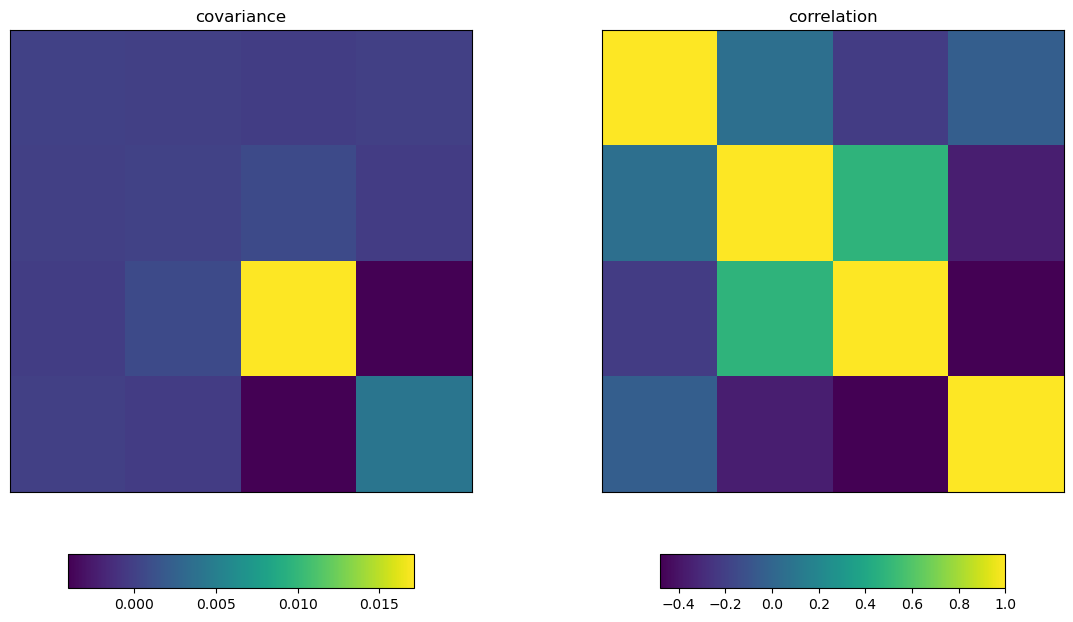

In [38]:
fid_cov = np.cov(fidu_vali_preds, rowvar=False)
fid_corr = np.corrcoef(fidu_vali_preds, rowvar=False)

fig, ax = plt.subplots(figsize=(14,8), ncols=2)

# covariance
im = ax[0].imshow(fid_cov)
ax[0].set(title="covariance")
ax[0].set_xticks([])
ax[0].set_yticks([])

fig.colorbar(im, ax=ax[0], orientation="horizontal", shrink=0.7, pad=0.1, aspect=10)

# correlation
im = ax[1].imshow(fid_corr)
ax[1].set(title="correlation")
ax[1].set_xticks([])
ax[1].set_yticks([])

fig.colorbar(im, ax=ax[1], orientation="horizontal", shrink=0.7, pad=0.1, aspect=10)

### emulator

In [45]:
np.mean(grid_preds, axis=1).shape

(2499, 4)

In [43]:
grid_preds.shape

(2499, 16, 4)

# MCMC

In [14]:
def log_posterior(X): 
    # convert to dataframe
    X = pd.DataFrame(X, columns=param_labels)
    X = X.join(obs_df, how="cross")

    # evaluate the normalizing flow
    log_prob = flow.log_prob(X)
    
    # enforce the prior
    log_prob = prior.log_posterior(X.loc[:,param_labels], log_prob, params=param_labels, conf=None)

    return log_prob

In [15]:
# emcee setup
np.random.seed(42)

nwalkers = 1024
p0 = np.random.normal(loc=parameters.get_fiducials(param_labels), scale=1e-3, size=(nwalkers, n_params))
print("Initial values in prior: ", np.all(prior.in_grid_prior(p0, params=param_labels))) 

Initial values in prior:  True


In [16]:
# sample burn in
sampler = EnsembleSampler(nwalkers, n_params, log_posterior, vectorize=True)
state = sampler.run_mcmc(p0, 100)
sampler.reset()

# run the actual chain
sampler.run_mcmc(state, 1000, progress=True)

# save the result
chain = sampler.get_chain(flat=True)
np.save(os.path.join(base_dir, model_dir, f"chain_{n_steps}_flow.npy"), chain)

100%|██████████| 1000/1000 [02:03<00:00,  8.07it/s]


# plot

### compare GP ABC to normalizing flow

100%|██████████| 15/15 [00:00<00:00, 1376.54it/s]


(<Figure size 2400x2400 with 36 Axes>,
 array([[<Axes: ylabel='$\\Omega_m$'>, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >, <Axes: >],
        [<Axes: ylabel='$\\sigma_8$'>, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >, <Axes: >],
        [<Axes: ylabel='$A_{IA}$'>, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >, <Axes: >],
        [<Axes: ylabel='$\\eta_{A_{IA}}$'>, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >, <Axes: >],
        [<Axes: ylabel='$b_g$'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >],
        [<Axes: xlabel='$\\Omega_m$', ylabel='$\\eta_{b_g}$'>,
         <Axes: xlabel='$\\sigma_8$'>, <Axes: xlabel='$A_{IA}$'>,
         <Axes: xlabel='$\\eta_{A_{IA}}$'>, <Axes: xlabel='$b_g$'>,
         <Axes: xlabel='$\\eta_{b_g}$'>]], dtype=object))

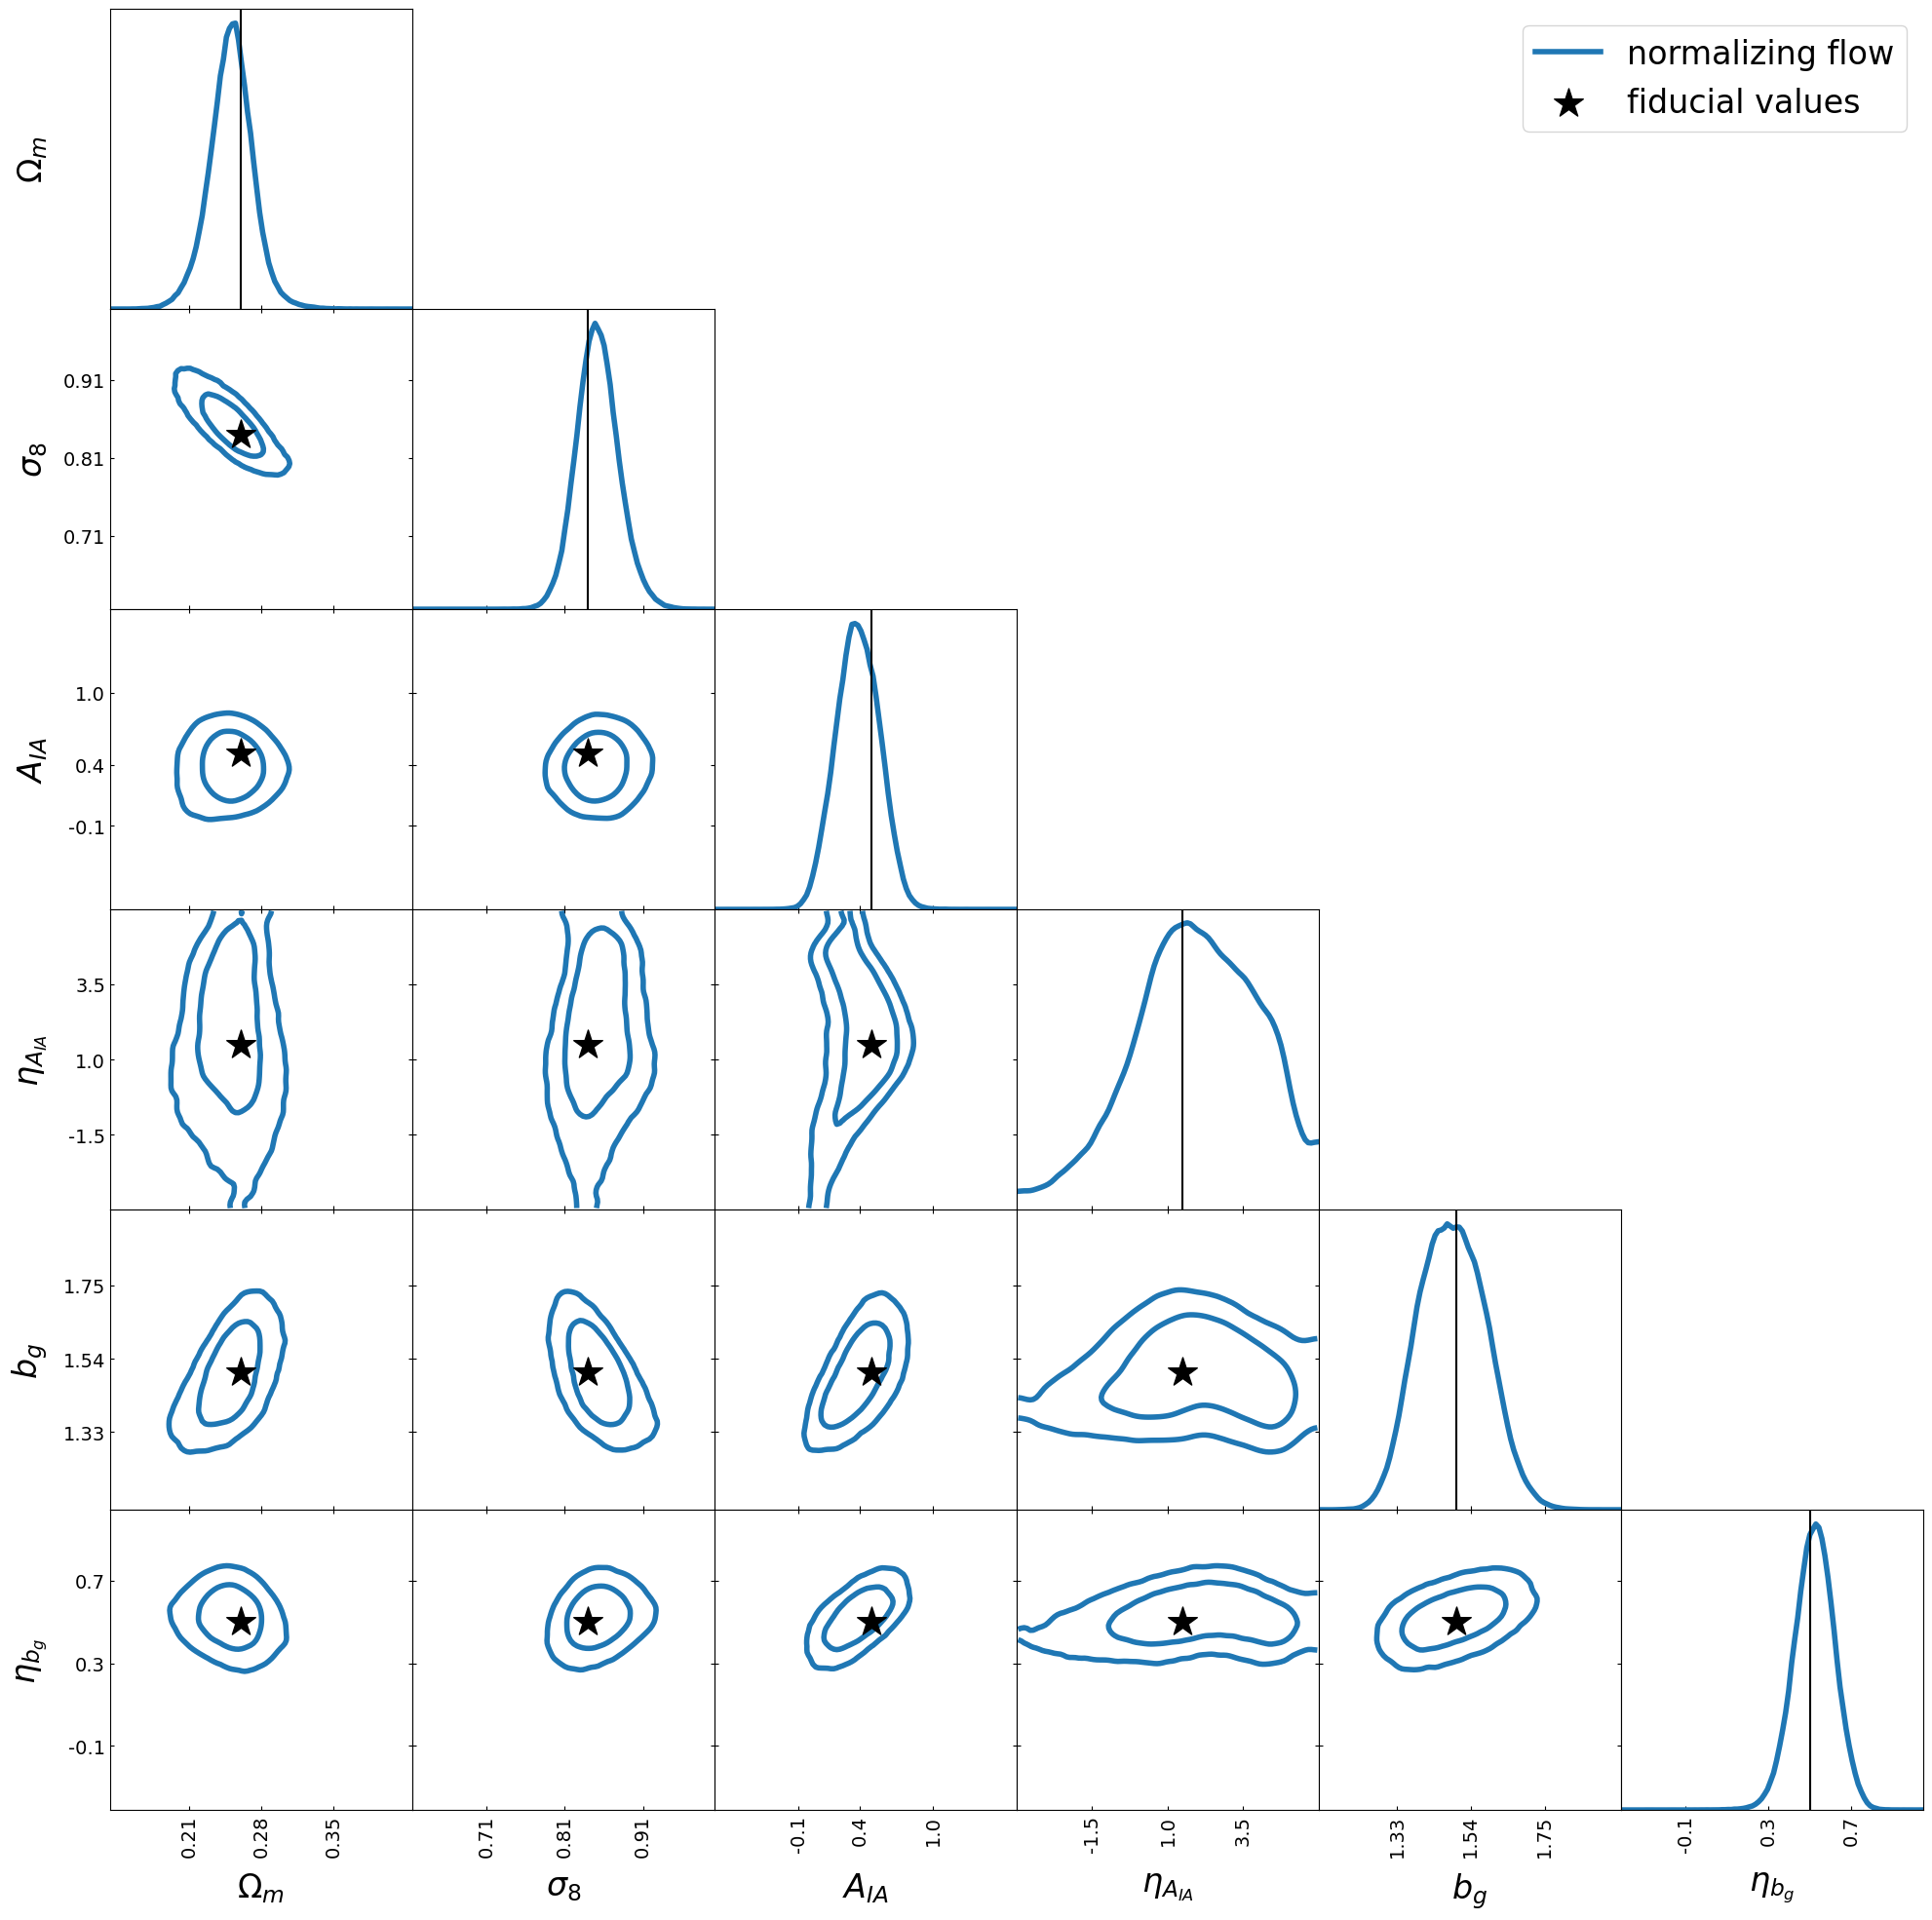

In [17]:
tri = TriangleChain(labels=param_latex, scatter_kwargs={"s": 500, "marker": "*", "zorder": 299})

# GP ABC
# gp_abc_chain = np.load(os.path.join(base_dir, model_dir, f"chain_{n_steps}.npy"))
# tri.contour_cl(gp_abc_chain, names=param_latex, label="GP ABC")

# normalizing flow
tri.contour_cl(chain, names=param_labels, label="normalizing flow")

# fiducial
tri.scatter(
    fiducial_point,
    label="fiducial values",
    plot_histograms_1D=False,
    color="k",
    show_legend=True,
    scatter_vline_1D=True,
)
# tri.fig.savefig(os.path.join(base_dir, model_dir, f"contours_{n_steps}_flow_only_long_training.png"), bbox_inches="tight", dpi=300)

### compare with and without survey systematics correction

In [18]:
# tri = TriangleChain(labels=param_labels, scatter_kwargs={"s": 500, "marker": "*", "zorder": 299})

# # with systematics
# chain = np.load(os.path.join(base_dir, model_dir, f"chain_{n_steps}_flow_survey_systematics.npy"))
# tri.contour_cl(chain, names=param_labels, label="flow, with survey systematics")

# # without systematics
# chain = np.load(os.path.join(base_dir, model_dir, f"chain_{n_steps}_flow_no_survey_systematics.npy"))
# tri.contour_cl(chain, names=param_labels, label="flow, without survey systematics")

# # fiducial
# tri.scatter(
#     fiducial_point,
#     label="fiducial values",
#     plot_histograms_1D=False,
#     color="k",
#     show_legend=True,
#     scatter_vline_1D=True,
# )
# tri.fig.savefig(os.path.join(base_dir, model_dir, f"contours_{n_steps}_flow_systematics.png"), bbox_inches="tight", dpi=300)